In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pinxau1000/radioml2018/datasets.desktop
/kaggle/input/datasets/pinxau1000/radioml2018/classes-fixed.json
/kaggle/input/datasets/pinxau1000/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5
/kaggle/input/datasets/pinxau1000/radioml2018/classes-fixed.txt
/kaggle/input/datasets/pinxau1000/radioml2018/LICENSE.TXT
/kaggle/input/datasets/pinxau1000/radioml2018/classes.txt


In [2]:
!pip install pyts -q
!pip install h5py scikit-learn matplotlib seaborn torch torchvision scipy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 25.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 97.8 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompa

In [3]:
# ============================================================
# Cell 0: 安装与导入依赖
# ============================================================
!pip install pyts -q
!pip install h5py scikit-learn matplotlib seaborn torch torchvision scipy -q

import os
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# 信号处理
from scipy import signal as sp_signal
from scipy.ndimage import zoom

# 时序图像转换（GASF / GADF / MTF / RP）
from pyts.image import GramianAngularField
from pyts.image import MarkovTransitionField
from pyts.image import RecurrencePlot

# PyTorch 核心
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

# 评估指标
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, roc_curve, auc
)

import warnings
warnings.filterwarnings('ignore')

# ── 固定随机种子 ─────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── 设备选择（自动使用GPU） ────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ 当前使用设备: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU型号 : {torch.cuda.get_device_name(0)}')
    print(f'   显存大小: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


✅ 当前使用设备: cuda
   GPU型号 : Tesla T4
   显存大小: 15.6 GB


In [4]:
# ============================================================
# Cell 1: 加载标签与SNR（内存友好，不加载X）
# ============================================================

HDF5_PATH = '/kaggle/input/datasets/pinxau1000/radioml2018/GOLD_XYZ_OSC.0001_1024.hdf5'

# RadioML 2018.01A 标准调制类别顺序（24种）
MOD_CLASSES = [
    'OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK',
    '16PSK', '32PSK', '16APSK', '32APSK', '64APSK',
    '128APSK', '16QAM', '32QAM', '64QAM', '128QAM',
    '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC',
    'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK'
]
NUM_MOD = len(MOD_CLASSES)

print('📖 读取 Y（调制标签）和 Z（SNR）...')
with h5py.File(HDF5_PATH, 'r') as f:
    Y_raw = f['Y'][:]   # shape: (N, 24)，One-hot 编码
    Z_raw = f['Z'][:]   # shape: (N, 1)

# One-hot 转为类别索引（0~23）
y_mod_full = np.argmax(Y_raw, axis=1).astype(np.int32)   # shape: (N,)
snr_full   = Z_raw.flatten().astype(np.int32)             # shape: (N,)
del Y_raw, Z_raw  # 立即释放内存

ALL_SNRS = sorted(np.unique(snr_full).tolist())   # [-20, -18, ..., +30]

print(f'✅ 加载完成！')
print(f'   总样本数    : {len(y_mod_full):,}')
print(f'   调制种类    : {NUM_MOD} 种')
print(f'   SNR 档位    : {len(ALL_SNRS)} 档，范围 {ALL_SNRS[0]} ~ {ALL_SNRS[-1]} dB')
print(f'\n调制类别列表:')
for i, m in enumerate(MOD_CLASSES):
    print(f'   [{i:2d}] {m}')


📖 读取 Y（调制标签）和 Z（SNR）...
✅ 加载完成！
   总样本数    : 2,555,904
   调制种类    : 24 种
   SNR 档位    : 26 档，范围 -20 ~ 30 dB

调制类别列表:
   [ 0] OOK
   [ 1] 4ASK
   [ 2] 8ASK
   [ 3] BPSK
   [ 4] QPSK
   [ 5] 8PSK
   [ 6] 16PSK
   [ 7] 32PSK
   [ 8] 16APSK
   [ 9] 32APSK
   [10] 64APSK
   [11] 128APSK
   [12] 16QAM
   [13] 32QAM
   [14] 64QAM
   [15] 128QAM
   [16] 256QAM
   [17] AM-SSB-WC
   [18] AM-SSB-SC
   [19] AM-DSB-WC
   [20] AM-DSB-SC
   [21] FM
   [22] GMSK
   [23] OQPSK


In [5]:
# ============================================================
# Cell 2: 分层均匀抽样（只建索引，不读X）
# ============================================================

SAMPLES_PER_MOD = 2000  # 每种调制方式抽取条数，共 24×10000 = 240,000 条

rng = np.random.default_rng(SEED)
per_snr = max(1, SAMPLES_PER_MOD // len(ALL_SNRS))

print(f'🎯 抽样计划：每种调制 {SAMPLES_PER_MOD:,} 条，每档SNR ≈ {per_snr} 条')
print(f'   调制种类数={NUM_MOD}，SNR档数={len(ALL_SNRS)}，预计总计≈{NUM_MOD*SAMPLES_PER_MOD:,} 条')
print('   构建索引中...')

selected_indices = []
for mod_id in range(NUM_MOD):
    mod_pool = np.where(y_mod_full == mod_id)[0]
    for snr_db in ALL_SNRS:
        candidates = mod_pool[snr_full[mod_pool] == snr_db]
        n_take = min(per_snr, len(candidates))
        if n_take > 0:
            chosen = rng.choice(candidates, size=n_take, replace=False)
            selected_indices.extend(chosen.tolist())

# 排序：保证HDF5顺序读取效率
selected_indices = np.array(sorted(selected_indices), dtype=np.int64)

y_mod_sel = y_mod_full[selected_indices]   # 子集调制标签
snr_sel   = snr_full[selected_indices]     # 子集SNR标签

print(f'\n✅ 抽样完成！子集总数: {len(selected_indices):,}')
print('\n各调制类别样本数（应均匀）:')
for i, name in enumerate(MOD_CLASSES):
    cnt = (y_mod_sel == i).sum()
    bar = '█' * (cnt // 200)
    print(f'  [{i:2d}] {name:<12} {cnt:5,} {bar}')


🎯 抽样计划：每种调制 2,000 条，每档SNR ≈ 76 条
   调制种类数=24，SNR档数=26，预计总计≈48,000 条
   构建索引中...

✅ 抽样完成！子集总数: 47,424

各调制类别样本数（应均匀）:
  [ 0] OOK          1,976 █████████
  [ 1] 4ASK         1,976 █████████
  [ 2] 8ASK         1,976 █████████
  [ 3] BPSK         1,976 █████████
  [ 4] QPSK         1,976 █████████
  [ 5] 8PSK         1,976 █████████
  [ 6] 16PSK        1,976 █████████
  [ 7] 32PSK        1,976 █████████
  [ 8] 16APSK       1,976 █████████
  [ 9] 32APSK       1,976 █████████
  [10] 64APSK       1,976 █████████
  [11] 128APSK      1,976 █████████
  [12] 16QAM        1,976 █████████
  [13] 32QAM        1,976 █████████
  [14] 64QAM        1,976 █████████
  [15] 128QAM       1,976 █████████
  [16] 256QAM       1,976 █████████
  [17] AM-SSB-WC    1,976 █████████
  [18] AM-SSB-SC    1,976 █████████
  [19] AM-DSB-WC    1,976 █████████
  [20] AM-DSB-SC    1,976 █████████
  [21] FM           1,976 █████████
  [22] GMSK         1,976 █████████
  [23] OQPSK        1,976 █████████


In [6]:
# ============================================================
# Cell 3: 实验设计配置
# ============================================================

# ── 已知调制（训练时见过）────────────────────────────────────
KNOWN_MODS = [
    'BPSK', 'QPSK', '8PSK', '16PSK',        # 相位键控（PSK）族
    'OOK', '4ASK', '8ASK',                   # 幅度键控（ASK/OOK）族
    '16QAM', '32QAM', '64QAM',               # 正交幅度调制（低阶QAM）族
    'AM-DSB-SC', 'AM-SSB-SC',               # 模拟调制（抑制载波）
    'GMSK', 'OQPSK'                          # 扩频/特殊调制
]

# ── 未知调制（训练时从未出现，只在测试集2中）─────────────────
UNKNOWN_MODS = [m for m in MOD_CLASSES if m not in KNOWN_MODS]

known_idx   = np.array([MOD_CLASSES.index(m) for m in KNOWN_MODS],   dtype=np.int32)
unknown_idx = np.array([MOD_CLASSES.index(m) for m in UNKNOWN_MODS], dtype=np.int32)

assert len(known_idx) + len(unknown_idx) == NUM_MOD, '调制划分有误！'

# ── SNR 区间规划 ──────────────────────────────────────────────
H0_SNR        = -20
TRAIN_H1_SNRS = [s for s in ALL_SNRS if -10 <= s <= 10]   # 11档（中等范围）
TEST1_H1_SNRS = [s for s in ALL_SNRS if (s < -10 or s > 10) and s != H0_SNR]
TEST2_H1_SNRS = [s for s in ALL_SNRS if s != H0_SNR]

print('=' * 62)
print('📋 实验设计确认')
print('=' * 62)
print(f'已知调制  ({len(KNOWN_MODS):2d}种): {KNOWN_MODS}')
print(f'未知调制  ({len(UNKNOWN_MODS):2d}种): {UNKNOWN_MODS}')
print(f'训练H1 SNR ({len(TRAIN_H1_SNRS):2d}档): {TRAIN_H1_SNRS}')
print(f'测试1 H1 SNR({len(TEST1_H1_SNRS):2d}档): {TEST1_H1_SNRS}')
print(f'测试2 H1 SNR({len(TEST2_H1_SNRS):2d}档): {TEST2_H1_SNRS}')
print(f'H0_SNR: {H0_SNR} dB（信号完全被噪声淹没，等价于无信号）')


📋 实验设计确认
已知调制  (14种): ['BPSK', 'QPSK', '8PSK', '16PSK', 'OOK', '4ASK', '8ASK', '16QAM', '32QAM', '64QAM', 'AM-DSB-SC', 'AM-SSB-SC', 'GMSK', 'OQPSK']
未知调制  (10种): ['32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-DSB-WC', 'FM']
训练H1 SNR (11档): [-10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10]
测试1 H1 SNR(14档): [-18, -16, -14, -12, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]
测试2 H1 SNR(25档): [-18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]
H0_SNR: -20 dB（信号完全被噪声淹没，等价于无信号）


In [7]:
# ============================================================
# Cell 4: 三阶段数据集索引构建 & 分层80/20划分
# ============================================================

def get_mask(y_arr, snr_arr, mod_indices, snr_list):
    """根据调制方式和SNR条件筛选样本，返回布尔掩码。"""
    return np.isin(y_arr, mod_indices) & np.isin(snr_arr, snr_list)


def generate_awgn(n_samples, snr_db_list, n_points=1024):
    """
    生成纯AWGN负样本（H0）。

    原理：σ = 1/sqrt(2×10^(SNR/10))，I,Q ~ N(0,σ²)
    输出 shape: (n_samples, 1024, 2)
    """
    if n_samples <= 0:
        return np.empty((0, n_points, 2), dtype=np.float32)
    per_snr = max(1, n_samples // len(snr_db_list))
    chunks  = []
    for snr_db in snr_db_list:
        sigma = 1.0 / np.sqrt(2.0 * 10 ** (snr_db / 10.0))
        chunks.append((np.random.randn(per_snr, n_points, 2) * sigma).astype(np.float32))
    arr = np.concatenate(chunks, axis=0)
    while len(arr) < n_samples:
        arr = np.concatenate([arr, arr], axis=0)
    return arr[:n_samples]


def shuffle_split80(arr, rng_obj):
    """关键：先打乱，再按80/20分层切分，保证SNR分布一致。"""
    arr = np.array(arr)
    rng_obj.shuffle(arr)
    n_tr = int(0.8 * len(arr))
    return arr[:n_tr], arr[n_tr:]


# ── 训练+验证集 ──────────────────────────────────────────────
print('📦 构建训练/验证集...')
mask_tv_h1  = get_mask(y_mod_sel, snr_sel, known_idx, TRAIN_H1_SNRS)
tv_h1_pos   = np.where(mask_tv_h1)[0];     n_h1_tv = len(tv_h1_pos)
mask_tv_h0d = get_mask(y_mod_sel, snr_sel, known_idx, [H0_SNR])
tv_h0d_pos  = np.where(mask_tv_h0d)[0];   n_h0d_tv = len(tv_h0d_pos)

n_awgn_need = max(0, n_h1_tv - n_h0d_tv)
awgn_tv     = generate_awgn(n_awgn_need, TRAIN_H1_SNRS)

n_h0_tv     = n_h0d_tv + len(awgn_tv)
n_final_tv  = min(n_h1_tv, n_h0_tv)
if n_final_tv < n_h1_tv:
    tv_h1_pos = rng.choice(tv_h1_pos, size=n_final_tv, replace=False)

# 分层80/20划分（先shuffle保证SNR均匀）
train_h1_pos,  val_h1_pos  = shuffle_split80(tv_h1_pos,  rng)
train_h0d_pos, val_h0d_pos = shuffle_split80(tv_h0d_pos, rng)
rng.shuffle(awgn_tv)
n_atr = int(0.8 * len(awgn_tv))
train_awgn, val_awgn = awgn_tv[:n_atr], awgn_tv[n_atr:]

print(f'  训练: H1={len(train_h1_pos):,}  H0_data={len(train_h0d_pos):,}  H0_awgn={len(train_awgn):,}')
print(f'  验证: H1={len(val_h1_pos):,}  H0_data={len(val_h0d_pos):,}  H0_awgn={len(val_awgn):,}')

# ── 测试集1：SNR泛化 ─────────────────────────────────────────
print('\n📦 构建测试集1（SNR泛化）...')
t1_h1_pos  = np.where(get_mask(y_mod_sel, snr_sel, known_idx, TEST1_H1_SNRS))[0]
awgn_t1    = generate_awgn(len(t1_h1_pos), TEST1_H1_SNRS)
snr_t1_h1  = snr_sel[t1_h1_pos]
print(f'  H1={len(t1_h1_pos):,}  H0_awgn={len(awgn_t1):,}')

# ── 测试集2：调制泛化（盲检测） ───────────────────────────────
print('\n📦 构建测试集2（调制泛化/盲检测）...')
t2_h1_pos  = np.where(get_mask(y_mod_sel, snr_sel, unknown_idx, TEST2_H1_SNRS))[0]
t2_h0d_pos = np.where(get_mask(y_mod_sel, snr_sel, unknown_idx, [H0_SNR]))[0]
n_awgn_t2  = max(0, len(t2_h1_pos) - len(t2_h0d_pos))
awgn_t2    = generate_awgn(n_awgn_t2, TEST2_H1_SNRS)
n_t2_final = min(len(t2_h1_pos), len(t2_h0d_pos) + len(awgn_t2))
t2_h1_pos  = rng.choice(t2_h1_pos, size=n_t2_final, replace=False)
snr_t2_h1  = snr_sel[t2_h1_pos]
mod_t2_h1  = y_mod_sel[t2_h1_pos]
print(f'  H1={len(t2_h1_pos):,}  H0_data={len(t2_h0d_pos):,}  H0_awgn={len(awgn_t2):,}')

print('\n✅ 全部索引构建完成！')
print(f'  总训练样本: ~{len(train_h1_pos)+len(train_h0d_pos)+len(train_awgn):,}')
print(f'  总验证样本: ~{len(val_h1_pos)+len(val_h0d_pos)+len(val_awgn):,}')


📦 构建训练/验证集...
  训练: H1=9,363  H0_data=851  H0_awgn=8,512
  验证: H1=2,341  H0_data=213  H0_awgn=2,128

📦 构建测试集1（SNR泛化）...
  H1=14,896  H0_awgn=14,896

📦 构建测试集2（调制泛化/盲检测）...
  H1=19,000  H0_data=760  H0_awgn=18,240

✅ 全部索引构建完成！
  总训练样本: ~18,726
  总验证样本: ~4,682


In [8]:
# ============================================================
# Cell 5: 8种时序图像模态转换函数
# ============================================================

IMG_SIZE = 128   # 统一图像尺寸：(8, 32, 32) 送入ResNet18


def normalize_01(img):
    """归一化到 [0, 1]，消除模态间数值范围差异。"""
    v = img.astype(np.float32)
    lo, hi = v.min(), v.max()
    if hi - lo < 1e-8:
        return np.zeros_like(v)
    return (v - lo) / (hi - lo + 1e-8)


def resize_2d(img, size=32):
    """将任意二维图像双线性插值缩放到 size×size。"""
    img = np.asarray(img, dtype=np.float32)
    h, w = img.shape
    out  = zoom(img, (size / h, size / w), order=1)
    out  = out[:size, :size]
    if out.shape[0] < size or out.shape[1] < size:
        out = np.pad(out, ((0, size-out.shape[0]), (0, size-out.shape[1])), mode='edge')
    return out.astype(np.float32)


def downsample_1d(x, size=32):
    """均匀降采样1024→size点，避免生成1024×1024的巨大图像。"""
    idx = np.linspace(0, len(x) - 1, size).astype(np.int32)
    return np.asarray(x, dtype=np.float32)[idx]


# ── 模态1：功率谱密度图（PSD） ───────────────────────────────
def make_psd_img(x, size=32):
    I, Q = x[:, 0], x[:, 1]
    _, Pxx = sp_signal.welch(I + 1j*Q, fs=1.0, nperseg=128, noverlap=64)
    log_psd = 10 * np.log10(np.abs(Pxx) + 1e-10)
    img_2d  = np.outer(normalize_01(log_psd), normalize_01(log_psd))
    return resize_2d(img_2d, size)


# ── 模态2：STFT幅度谱图 ──────────────────────────────────────
def make_stft_img(x, size=32):
    I, Q = x[:, 0], x[:, 1]
    _, _, Zxx = sp_signal.stft(I + 1j*Q, fs=1.0, nperseg=64, noverlap=32, boundary=None)
    log_amp = 10 * np.log10(np.abs(Zxx) + 1e-10)
    return resize_2d(normalize_01(log_amp), size)


# ── 模态3 & 4：GASF / GADF ───────────────────────────────────
def make_gasf_gadf(x, size=32):
    amp_ds = downsample_1d(np.sqrt(x[:,0]**2 + x[:,1]**2), size).reshape(1, -1)
    gasf = normalize_01(GramianAngularField(image_size=size, method='summation').fit_transform(amp_ds)[0])
    gadf = normalize_01(GramianAngularField(image_size=size, method='difference').fit_transform(amp_ds)[0])
    return gasf, gadf


# ── 模态5 & 6：MTF / MDF ─────────────────────────────────────
def make_mtf_mdf(x, size=32):
    amp_ds = downsample_1d(np.sqrt(x[:,0]**2 + x[:,1]**2), size).reshape(1, -1)
    mtf    = normalize_01(MarkovTransitionField(image_size=size, n_bins=8).fit_transform(amp_ds)[0])
    row_sum = mtf.sum(axis=1, keepdims=True) + 1e-8
    mdf    = normalize_01(mtf / row_sum)
    return mtf, mdf


# ── 模态7 & 8：RP / RPM ──────────────────────────────────────
def make_rp_rpm(x, size=32):
    amp_ds = downsample_1d(np.sqrt(x[:,0]**2 + x[:,1]**2), size).reshape(1, -1)
    rp  = RecurrencePlot(threshold='point', percentage=20).transform(amp_ds)[0].astype(np.float32)
    rpm = RecurrencePlot(threshold='point', percentage=5 ).transform(amp_ds)[0].astype(np.float32)
    return rp, rpm


# ── 整合：生成 (8, 32, 32) 多模态图像张量 ────────────────────
def make_8modal_image(x, size=32):
    """
    将一条IQ信号转换为8通道多模态图像。

    通道顺序:
        0: PSD     功率谱密度
        1: STFT    幅度谱
        2: GASF    角度和场
        3: GADF    角度差场
        4: MTF     马尔可夫转移场
        5: MDF     边缘分布场
        6: RP      递归图（宏观，percentage=20）
        7: RPM     递归图（微观，percentage=5）

    输入 x: (1024, 2)
    输出  : (8, size, size)
    """
    psd            = make_psd_img(x, size)
    stft_img       = make_stft_img(x, size)
    gasf, gadf     = make_gasf_gadf(x, size)
    mtf,  mdf      = make_mtf_mdf(x, size)
    rp,   rpm      = make_rp_rpm(x, size)
    return np.stack([psd, stft_img, gasf, gadf, mtf, mdf, rp, rpm], axis=0).astype(np.float32)


print('✅ 8种模态转换函数定义完成！')
print('   输入: IQ信号 (1024, 2)')
print('   输出: 多模态图像 (8, 32, 32)')
MODAL_NAMES = ['PSD（功率谱密度）', 'STFT（幅度谱）', 'GASF（角度和场）', 'GADF（角度差场）',
               'MTF（马尔可夫转移场）', 'MDF（边缘分布场）', 'RP（递归图·宏观）', 'RPM（递归图·微观）']
for i, n in enumerate(MODAL_NAMES):
    print(f'   通道{i}: {n}')


✅ 8种模态转换函数定义完成！
   输入: IQ信号 (1024, 2)
   输出: 多模态图像 (8, 32, 32)
   通道0: PSD（功率谱密度）
   通道1: STFT（幅度谱）
   通道2: GASF（角度和场）
   通道3: GADF（角度差场）
   通道4: MTF（马尔可夫转移场）
   通道5: MDF（边缘分布场）
   通道6: RP（递归图·宏观）
   通道7: RPM（递归图·微观）


样本信息：调制=OOK，SNR=-8 dB
多模态图像形状：(8, 128, 128)  →  (8通道, 32×32)


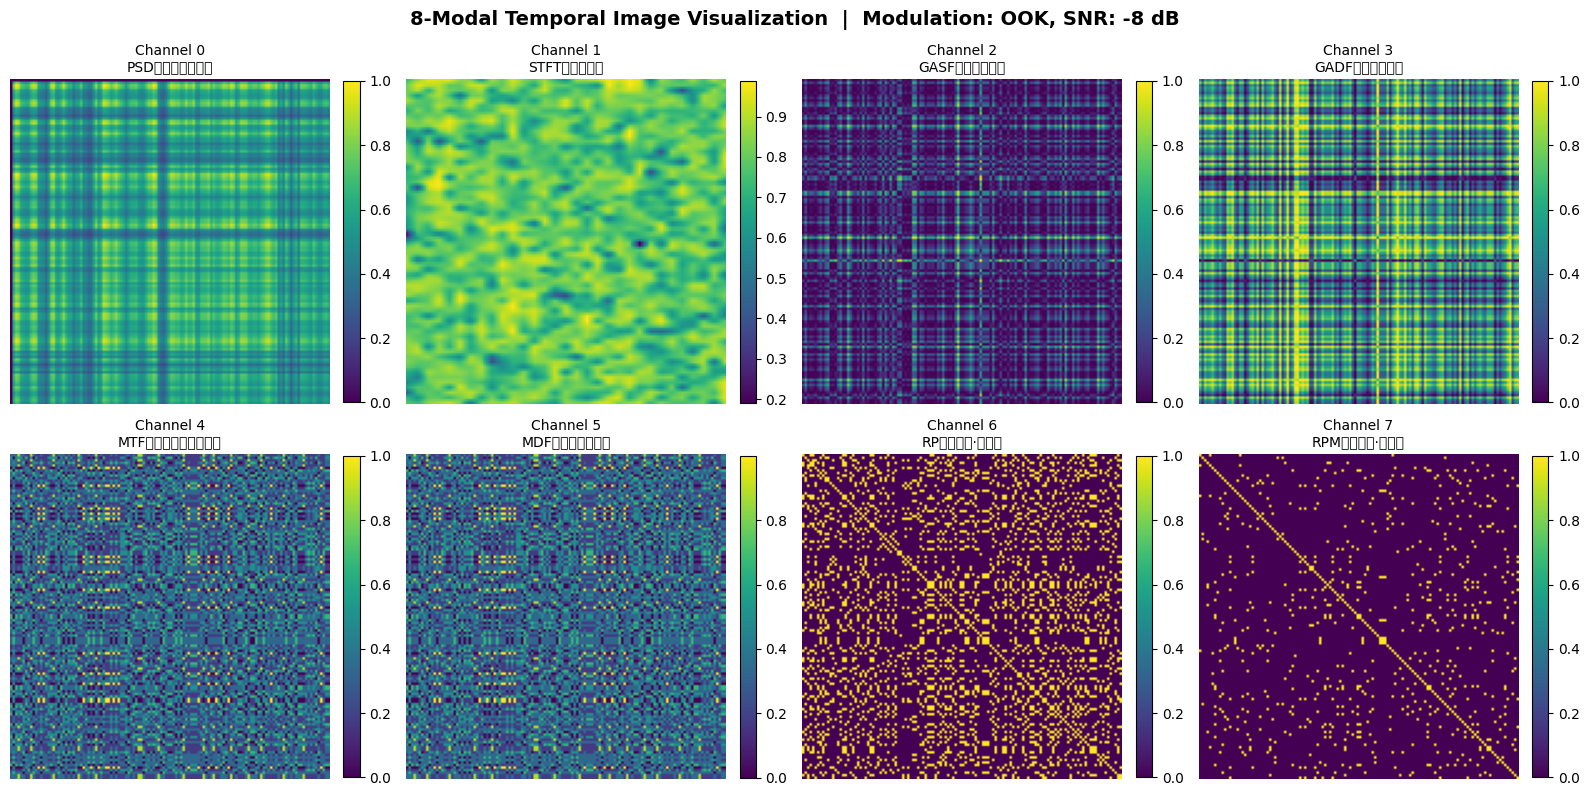

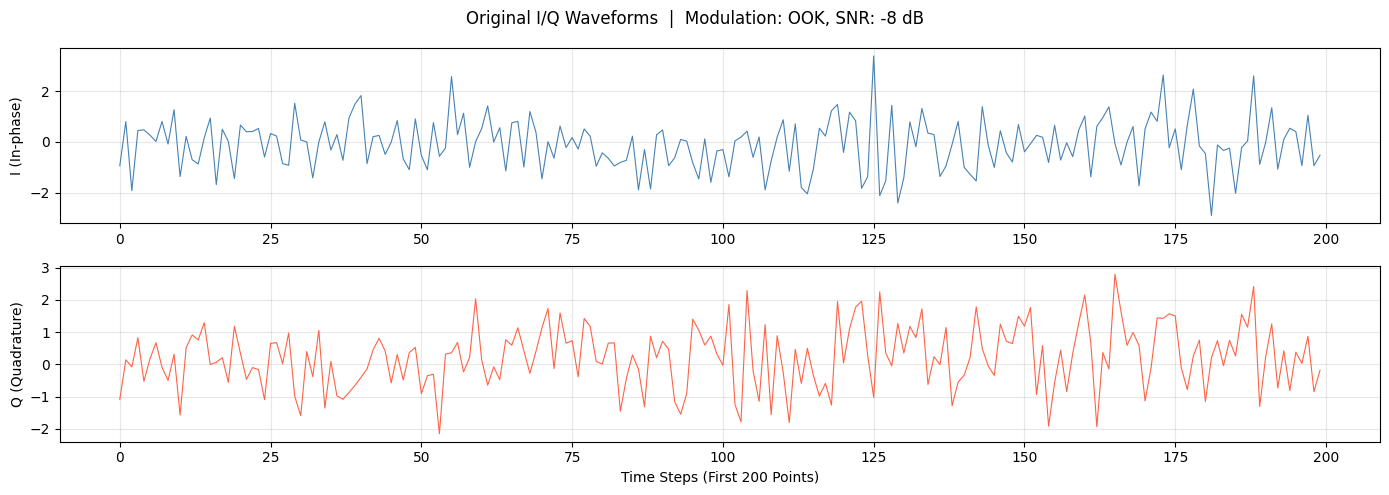

In [9]:
# ============================================================
# Cell 6: 可视化8种模态图像 (8-Modal Images Visualization)
# ============================================================

# 从HDF5读取一条样本做可视化
sample_rel_idx  = 500
sample_hdf5_row = int(selected_indices[sample_rel_idx])
mod_name = MOD_CLASSES[y_mod_sel[sample_rel_idx]]
snr_val  = snr_sel[sample_rel_idx]

with h5py.File(HDF5_PATH, 'r') as f:
    x_sample = f['X'][sample_hdf5_row]

if x_sample.shape == (2, 1024):
    x_sample = x_sample.T
x_sample = x_sample.astype(np.float32)
power    = float(np.mean(x_sample ** 2)) + 1e-8
x_sample = x_sample / np.sqrt(power)

print(f'样本信息：调制={mod_name}，SNR={snr_val} dB')

# 生成8种模态图像
imgs_8 = make_8modal_image(x_sample, IMG_SIZE)
print(f'多模态图像形状：{imgs_8.shape}  →  (8通道, 32×32)')

# ── 绘制8种模态 ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
# 将标题更改为英文，避免Kaggle上中文显示为方块
fig.suptitle(f'8-Modal Temporal Image Visualization  |  Modulation: {mod_name}, SNR: {snr_val} dB',
             fontsize=14, fontweight='bold')

# 如果你的 MODAL_NAMES 定义的是中文（例如 ['瞬时振幅', ...]），
# 可以考虑在这里或者全局定义一个对应的英文名字映射列表，这里假设使用英文或索引展示。
# 如果 MODAL_NAMES 本身就是英文，则可以直接使用。
for i, (ax, name) in enumerate(zip(axes.flat, MODAL_NAMES)):
    im = ax.imshow(imgs_8[i], cmap='viridis', aspect='auto')
    ax.set_title(f'Channel {i}\n{name}', fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# ── 原始IQ波形 ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 5))
# 将标题及坐标轴标签更改为英文
fig.suptitle(f'Original I/Q Waveforms  |  Modulation: {mod_name}, SNR: {snr_val} dB', fontsize=12)
axes[0].plot(x_sample[:200, 0], lw=0.8, color='steelblue')
axes[0].set_ylabel('I (In-phase)')
axes[0].grid(alpha=0.3)

axes[1].plot(x_sample[:200, 1], lw=0.8, color='tomato')
axes[1].set_ylabel('Q (Quadrature)')
axes[1].set_xlabel('Time Steps (First 200 Points)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# Cell 7: 纯净版 Dataset (BiLSTM 基准复现)
# 
# 修改说明：
# 1. 移除所有训练集数据增强（SNR Jitter, Noise Perturbation）。
# 2. 保留图像生成逻辑以维持代码结构，但在 BiLSTM 训练中将被忽略。
# 3. 保持功率归一化，确保模型学习的是波形结构而非绝对能量。
# ============================================================

def make_time_features(x):
    """
    构造 BiLSTM 时域输入：[I, Q, 瞬时幅度, 展开相位]
    """
    I, Q  = x[:, 0], x[:, 1]
    amp   = np.sqrt(I**2 + Q**2)
    # 使用 np.unwrap 使得相位连续，这是 BiLSTM 提取频率特征的关键
    phase = np.unwrap(np.angle(I + 1j*Q))
    feat  = np.stack([I, Q, amp, phase], axis=1).astype(np.float32)
    
    # 逐通道标准化 (Z-score)
    mean  = feat.mean(axis=0, keepdims=True)
    std   = feat.std(axis=0,  keepdims=True) + 1e-6
    return ((feat - mean) / std).astype(np.float32)


class DualModalDataset(Dataset):
    def __init__(self, hdf5_path, hdf5_positions, hdf5_labels,
                 awgn_data, selected_indices, img_size=64, mode='test'):
        self.hdf5_path   = hdf5_path
        self.hdf5_rows   = selected_indices[hdf5_positions].astype(np.int64)
        self.hdf5_labels = np.array(hdf5_labels, dtype=np.int64)
        self.awgn_data   = awgn_data
        self.n_hdf5      = len(self.hdf5_rows)
        self.total       = self.n_hdf5 + len(self.awgn_data)
        self.img_size    = img_size
        self.mode        = mode 
        self._f          = None

    def _open(self):
        if self._f is None:
            self._f = h5py.File(self.hdf5_path, 'r')

    def __len__(self): return self.total

    def __getitem__(self, idx):
        # 1. 读取原始数据 (HDF5 或 AWGN)
        if idx < self.n_hdf5:
            self._open()
            x = self._f['X'][int(self.hdf5_rows[idx])]
            if x.shape == (2, 1024): x = x.T
            elif x.shape != (1024, 2): x = x.reshape(1024, 2)
            y = int(self.hdf5_labels[idx])
        else:
            x = self.awgn_data[idx - self.n_hdf5]
            y = 0

        x = np.asarray(x, dtype=np.float32)

        # --- 【已移除增强逻辑】 ---
        # 此处不再进行 jitter 和 noise 注入，保证复现的严谨性

        # 2. 功率归一化 (Baseline 必须包含此步，否则不同 SNR 无法统一处理)
        power = float(np.mean(x ** 2)) + 1e-8
        x = x / np.sqrt(power)

        # 3. 生成特征
        x_time = make_time_features(x)            
        x_img  = make_8modal_image(x, self.img_size)  

        return (torch.from_numpy(x_time),
                torch.from_numpy(x_img),
                torch.tensor(y, dtype=torch.long))

    def __del__(self):
        if self._f is not None:
            try: self._f.close()
            except: pass

# ── 重新实例化 DataLoader ──────────────────────────────────────
BATCH_SIZE = 64 

def _make_ds(h1_pos, h0d_pos, awgn_arr, mode='test'):
    return DualModalDataset(
        HDF5_PATH,
        np.concatenate([h1_pos, h0d_pos]),
        np.concatenate([np.ones(len(h1_pos), dtype=np.int64),
                        np.zeros(len(h0d_pos), dtype=np.int64)]),
        awgn_arr, selected_indices, IMG_SIZE, mode=mode)

# 全部设为 'test' 模式，即关闭所有潜在的增强
train_ds  = _make_ds(train_h1_pos, train_h0d_pos, train_awgn, mode='test')
val_ds    = _make_ds(val_h1_pos,   val_h0d_pos,   val_awgn,   mode='test')
test1_ds  = DualModalDataset(HDF5_PATH, t1_h1_pos,
                np.ones(len(t1_h1_pos), dtype=np.int64), awgn_t1, selected_indices, IMG_SIZE, mode='test')
test2_ds  = _make_ds(t2_h1_pos, t2_h0d_pos, awgn_t2, mode='test')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test1_loader = DataLoader(test1_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test2_loader = DataLoader(test2_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f'✅ 基准测试数据集已就绪：已关闭所有数据增强。')

✅ 基准测试数据集已就绪：已关闭所有数据增强。


In [11]:
import torch
import torch.nn as nn

# ============================================================
# Cell 8: BiLSTM 基准模型定义 (Reproduction Version)
# 
# 核心逻辑：
# 1. 输入：(Batch, 1024, 4) -> [I, Q, Amplitude, Phase]
# 2. 骨干：2层双向 LSTM
# 3. 输出：标准的 Logits (用于 CrossEntropyLoss)
# ============================================================

class BiLSTMBaseline(nn.Module):
    def __init__(self, input_size=4, hidden_size=64, num_layers=2, num_classes=2):
        super(BiLSTMBaseline, self).__init__()
        
        # 标准双向 LSTM
        # batch_first=True 确保输入维度为 (B, T, C)
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers=num_layers, 
            batch_first=True, 
            bidirectional=True, 
            dropout=0.3
        )
        
        # 线性分类头
        # 因为是双向，所以输入维度是 hidden_size * 2
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x_time, x_img=None):
        """
        注意：为了兼容之前的训练循环，我们保留了 x_img 参数，但在内部完全不使用它。
        """
        # 1. 通过 LSTM 提取时序特征
        # out shape: (Batch, 1024, hidden_size * 2)
        out, _ = self.lstm(x_time)
        
        # 2. 特征聚合：取最后一个时间步的输出
        # 也可以使用 out.mean(dim=1) 进行全局平均池化
        last_step = out[:, -1, :] 
        
        # 3. 分类得到 Logits
        logits = self.classifier(last_step)
        return logits

# ── 实例化基准模型 ─────────────────────────────────────────────
model = BiLSTMBaseline(input_size=4, hidden_size=64, num_layers=2).to(DEVICE)

print(f'🚀 BiLSTM 基准模型已就绪！')
print(f'   - 架构: 2-Layer Bidirectional LSTM')
print(f'   - 输入特征: 4 (I, Q, Amp, Phase)')
print(f'   - 参数量: {sum(p.numel() for p in model.parameters()):,}')

🚀 BiLSTM 基准模型已就绪！
   - 架构: 2-Layer Bidirectional LSTM
   - 输入特征: 4 (I, Q, Amp, Phase)
   - 参数量: 143,554


In [12]:
import torch.nn as nn
import torch.optim as optim

# ============================================================
# Cell 9: BiLSTM 基准训练循环 (Reproduction Version)
# 
# 核心逻辑：
# 1. 损失函数：标准 CrossEntropyLoss (适合二分类/多分类)
# 2. 优化器：标准 Adam (学习率 1e-3)
# 3. 调度器：余弦退火 (CosineAnnealing)
# ============================================================

# ── 1. 定义损失函数 ──────────────────────────────────────────
# 基准测试不需要 EDL，直接用最通用的交叉熵
criterion = nn.CrossEntropyLoss()

# ── 2. 配置优化器 ────────────────────────────────────────────
# 基准模型结构简单，直接对所有参数进行优化
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# 余弦退火调度器 (保持平滑下降)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)

# ── 3. 训练与验证函数 (简化版) ─────────────────────────────────
def run_epoch_baseline(model, loader, criterion, optimizer, device, train=True):
    model.train() if train else model.eval()
    total_loss = total_correct = total_n = 0
    
    for x_time, x_img, yb in loader:
        # 将数据移至设备 (注意：基准模型只用 x_time)
        x_time, yb = x_time.to(device), yb.to(device)
        
        if train:
            optimizer.zero_grad()
            # 前向传播得到标准的 Logits
            logits = model(x_time) 
            loss = criterion(logits, yb)
            loss.backward()
            # 梯度裁剪 (防止 LSTM 梯度爆炸)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        else:
            with torch.no_grad():
                logits = model(x_time)
                loss = criterion(logits, yb)
        
        # 计算准确率
        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == yb).sum().item()
        total_loss += loss.item() * len(yb)
        total_n += len(yb)
        
    return total_loss / total_n, total_correct / total_n

# ── 4. 正式开始训练循环 (带早停) ───────────────────────────────
NUM_EPOCHS = 20
PATIENCE = 5
early_stop_counter = 0

history = {'tr_loss': [], 'val_loss': [], 'tr_acc': [], 'val_acc': [], 'lr': []}
best_val_loss = float('inf')
best_state = None

print(f"🚀 开始复现 BiLSTM 基准实验 | 模式: Standard Baseline")
print(f"{'Ep':>4} | {'TrLoss':>8} | {'TrAcc':>8} | {'ValLoss':>8} | {'ValAcc':>8} | {'LR':>8}")
print("-" * 70)

for ep in range(1, NUM_EPOCHS + 1):
    # 执行训练和验证
    tr_l, tr_a = run_epoch_baseline(model, train_loader, criterion, optimizer, DEVICE, train=True)
    vl_l, vl_a = run_epoch_baseline(model, val_loader, criterion, optimizer, DEVICE, train=False)
    
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    
    history['tr_loss'].append(tr_l); history['val_loss'].append(vl_l)
    history['tr_acc'].append(tr_a);  history['val_acc'].append(vl_a)
    
    # 保存最优模型
    if vl_l < best_val_loss:
        best_val_loss = vl_l
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        early_stop_counter = 0
        status = "⭐ (Best)"
    else:
        early_stop_counter += 1
        status = f" (Patience: {early_stop_counter}/{PATIENCE})"

    print(f"{ep:4d} | {tr_l:8.4f} | {tr_a:7.2%} | {vl_l:8.4f} | {vl_a:7.2%} | {current_lr:8.2e} {status}")

    if early_stop_counter >= PATIENCE:
        print(f"\n🛑 早停触发！")
        break

# 加载最优权重
model.load_state_dict(best_state)
print(f"\n🏆 基准训练完成！最优验证损失: {best_val_loss:.4f}")

🚀 开始复现 BiLSTM 基准实验 | 模式: Standard Baseline
  Ep |   TrLoss |    TrAcc |  ValLoss |   ValAcc |       LR
----------------------------------------------------------------------
   1 |   0.6397 |  60.93% |   0.5514 |  82.85% | 1.00e-03 ⭐ (Best)
   2 |   0.5288 |  76.26% |   0.5938 |  77.57% | 9.94e-04  (Patience: 1/5)
   3 |   0.6759 |  57.03% |   0.6929 |  50.00% | 9.76e-04  (Patience: 2/5)
   4 |   0.5679 |  69.36% |   0.4107 |  83.70% | 9.46e-04 ⭐ (Best)
   5 |   0.3977 |  83.55% |   0.4384 |  83.45% | 9.05e-04  (Patience: 1/5)
   6 |   0.3759 |  84.51% |   0.3183 |  86.95% | 8.54e-04 ⭐ (Best)
   7 |   0.3647 |  85.07% |   0.3727 |  85.73% | 7.94e-04  (Patience: 1/5)
   8 |   0.3671 |  85.11% |   0.3174 |  87.76% | 7.27e-04 ⭐ (Best)
   9 |   0.3560 |  85.75% |   0.3417 |  85.69% | 6.55e-04  (Patience: 1/5)
  10 |   0.3477 |  86.16% |   0.3291 |  86.03% | 5.79e-04  (Patience: 2/5)
  11 |   0.3423 |  86.48% |   0.3094 |  88.12% | 5.01e-04 ⭐ (Best)
  12 |   0.3237 |  87.20% |   0.3354 |  8

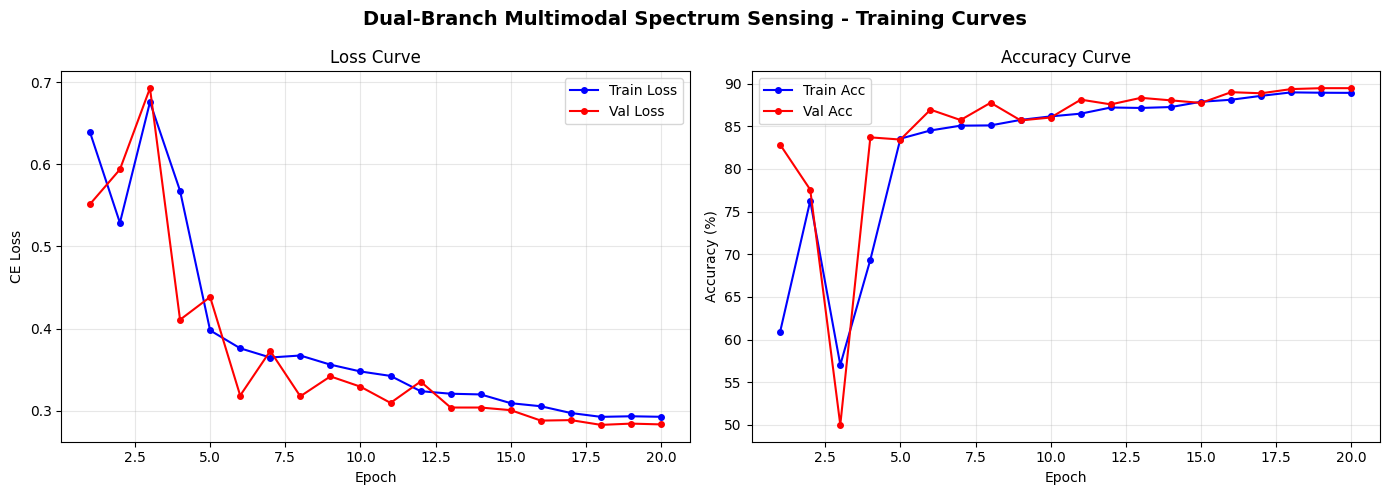

In [13]:
# ============================================================
# Cell 10: 训练曲线可视化
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dual-Branch Multimodal Spectrum Sensing - Training Curves', fontsize=14, fontweight='bold')
eps = range(1, len(history['tr_loss']) + 1)

axes[0].plot(eps, history['tr_loss'], 'b-o', ms=4, label='Train Loss')
axes[0].plot(eps, history['val_loss'], 'r-o', ms=4, label='Val Loss')
axes[0].set_title('Loss Curve'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('CE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(eps, [x*100 for x in history['tr_acc']], 'b-o', ms=4, label='Train Acc')
axes[1].plot(eps, [x*100 for x in history['val_acc']], 'r-o', ms=4, label='Val Acc')
axes[1].set_title('Accuracy Curve'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [14]:
import pandas as pd
import torch
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, roc_curve, auc
)

# ============================================================
# Cell 11: 综合性能评估与学术指标汇总表 (基准复现版)
# ============================================================

def predict_baseline(model, loader, device):
    """
    对标准 Logits 输出的模型进行推理，使用 Softmax 计算概率
    """
    model.eval()
    preds_all, trues_all, probs_all = [], [], []
    
    with torch.no_grad():
        for x_time, x_img, yb in loader:
            # 基准模型只使用 x_time，但为了兼容性我们依然从 loader 取出两者
            x_time = x_time.to(device)
            
            # 1. 前向传播得到 Logits
            logits = model(x_time)
            
            # 2. 使用标准 Softmax 转化为概率
            probs = torch.softmax(logits, dim=1)
            
            # 3. 取最大概率作为预测类别
            preds = torch.argmax(probs, dim=1)
            
            preds_all.extend(preds.cpu().numpy())
            trues_all.extend(yb.numpy())
            probs_all.extend(probs.cpu().numpy())
            
    return np.array(preds_all), np.array(trues_all), np.array(probs_all)

def calculate_all_metrics(y_true, y_pred, y_prob):
    """
    计算核心学术指标，保留绘图数据
    """
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0) # 即 Pd
    f1  = f1_score(y_true, y_pred, zero_division=0)
    
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    
    Pd  = TP / (TP + FN + 1e-10)
    Pfa = FP / (FP + TN + 1e-10)
    
    # 使用 Softmax 概率中的 H1 列计算 ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])
    roc_auc = auc(fpr, tpr)
    
    return {
        "ACC": acc,
        "Precision": pre,
        "Recall (Pd)": rec,
        "F1-score": f1,
        "Pfa": Pfa,
        "AUC": roc_auc,
        "cm": cm,
        "fpr": fpr,
        "tpr": tpr
    }

# ── 1. 执行三阶段推理 ──────────────────────────────────────────
print('🔍 正在进行基准模型三阶段推理评估 (Standard Softmax 模式)...')
# 验证集
pred_v,  true_v,  prob_v  = predict_baseline(model, val_loader,   DEVICE)
# 测试集 1 (SNR 泛化)
pred_t1, true_t1, prob_t1 = predict_baseline(model, test1_loader, DEVICE)
# 测试集 2 (调制泛化/盲检测)
pred_t2, true_t2, prob_t2 = predict_baseline(model, test2_loader, DEVICE)

# ── 2. 计算各阶段指标 ──────────────────────────────────────────
m_v  = calculate_all_metrics(true_v,  pred_v,  prob_v)
m_t1 = calculate_all_metrics(true_t1, pred_t1, prob_t1)
m_t2 = calculate_all_metrics(true_t2, pred_t2, prob_t2)

# ── 3. 组装成 Pandas DataFrame ─────────────────────────────────
table_keys = ["ACC", "F1-score", "Precision", "Recall (Pd)", "Pfa", "AUC"]
results_df = pd.DataFrame({
    "Validation (Baseline)": {k: m_v[k] for k in table_keys},
    "Test Set 1 (SNR Gen.)": {k: m_t1[k] for k in table_keys},
    "Test Set 2 (Mod Gen.)": {k: m_t2[k] for k in table_keys}
}).T

# ── 4. 格式化并显示表格 ────────────────────────────────────────
print("\n" + "="*35 + " 基准模型性能对比表 " + "="*35)
display(results_df.style.background_gradient(cmap='Blues', axis=0).format("{:.4f}"))
print("="*90)

# ── 5. 导师深度点评 ───────────────────────────────────────────
print("\n💡 基准复现提示:")
print("1. 现在的评估完全基于时域 BiLSTM 的原始表现。")
print("2. 请记录下这个表格中的数值，它们将作为你后续‘多模态+EDL’改进效果的参照物。")

🔍 正在进行基准模型三阶段推理评估 (Standard Softmax 模式)...

=================================== 基准模型性能对比表 ===================================


,ACC,F1-score,Precision,Recall (Pd),Pfa,AUC
Validation (Baseline),0.8936,0.8834,0.9772,0.8061,0.0188,0.9168
Test Set 1 (SNR Gen.),0.8505,0.8285,0.9717,0.7220,0.0210,0.8586
Test Set 2 (Mod Gen.),0.8666,0.8498,0.9719,0.7549,0.0218,0.8845



💡 基准复现提示:
1. 现在的评估完全基于时域 BiLSTM 的原始表现。
2. 请记录下这个表格中的数值，它们将作为你后续‘多模态+EDL’改进效果的参照物。


✅ 缺失变量已自动补全，现在可以开始绘图了！


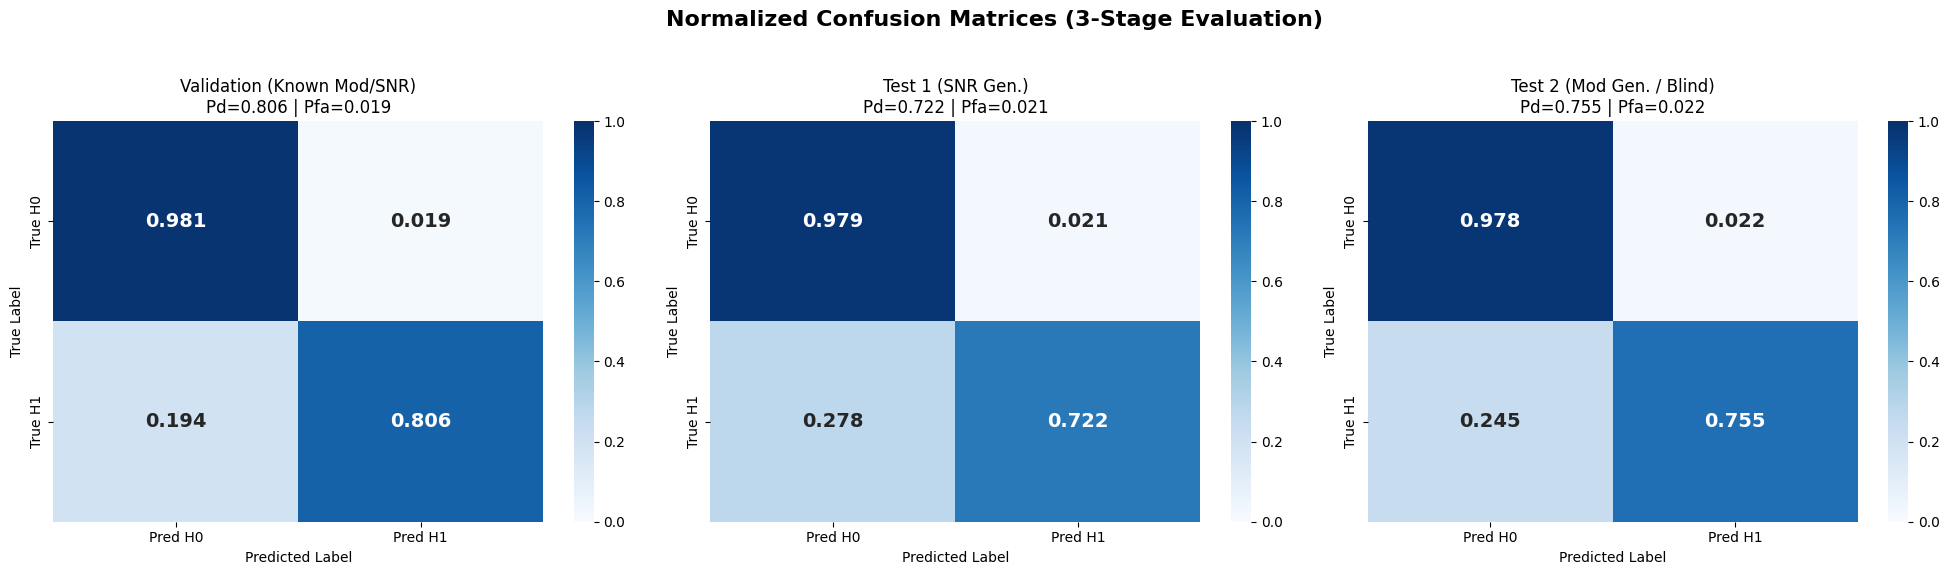

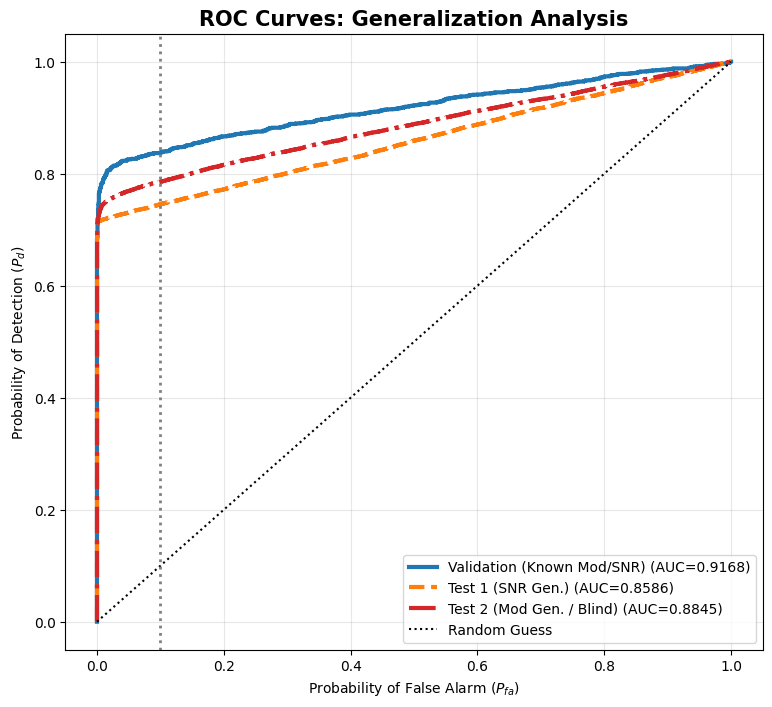

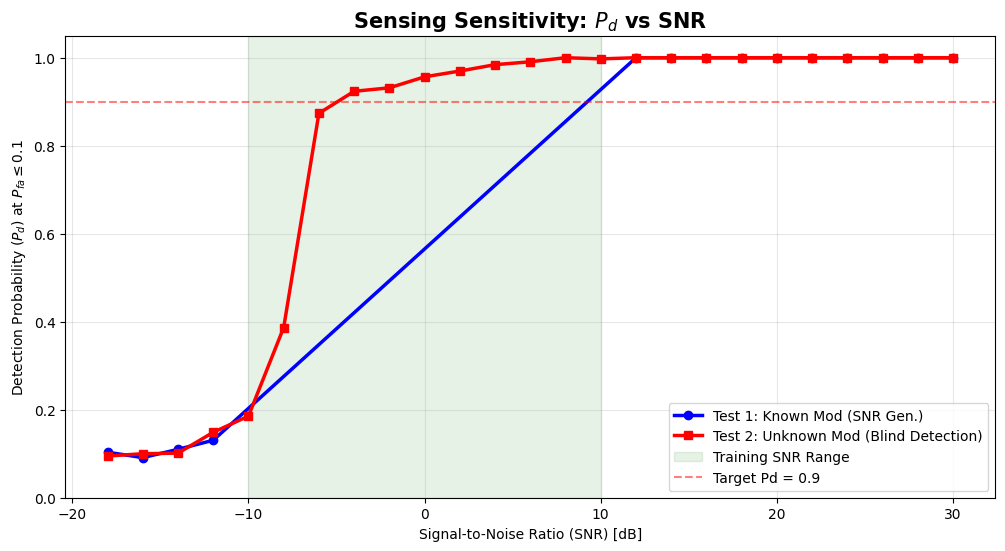


🌡️ Generating Heatmap for Test Set 2 (Blind Detection)...


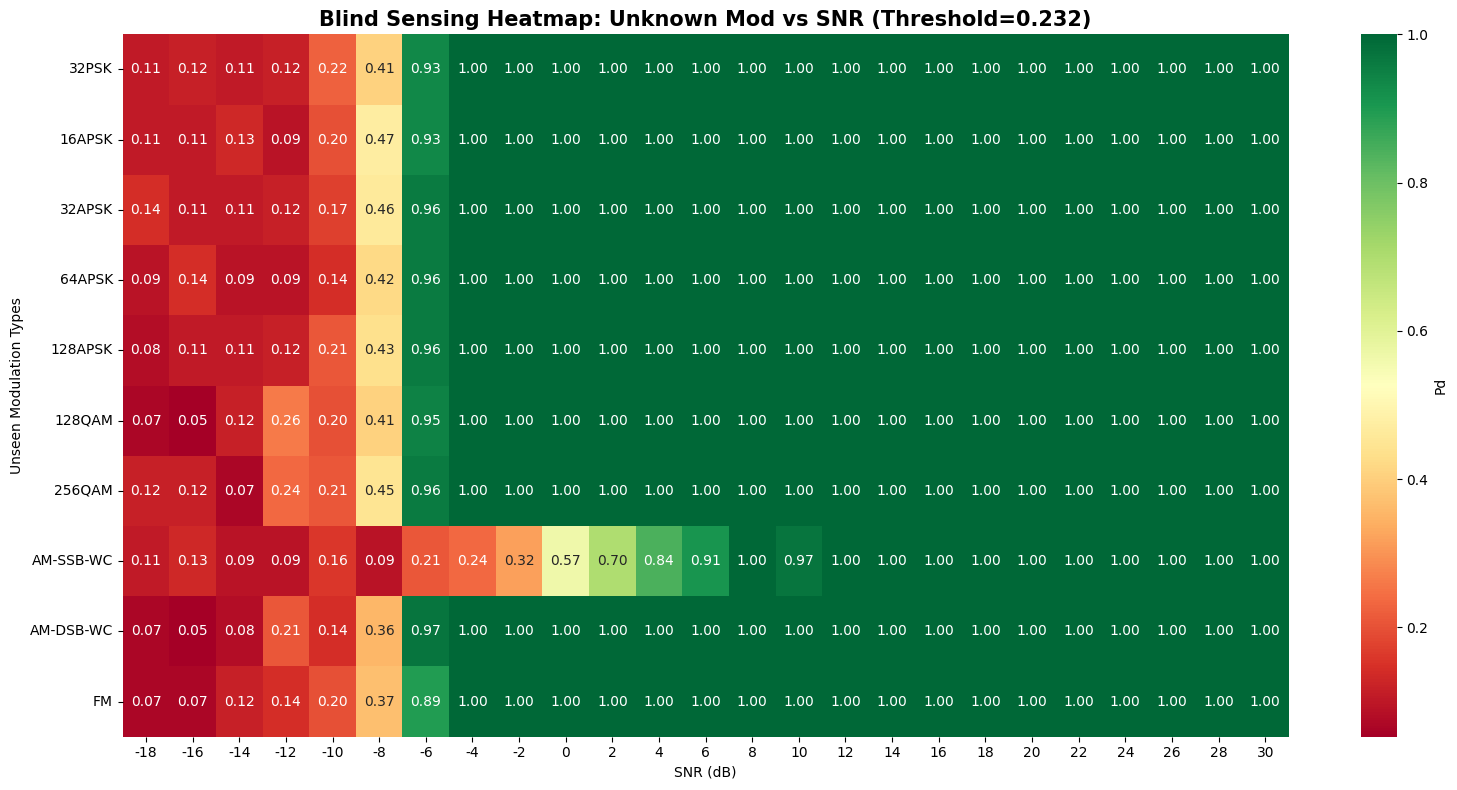

In [15]:
# ============================================================
# 🛠️ 快速补丁：现场生成缺失的元数据变量，无需修改之前的 Cell
# ============================================================
import numpy as np

# 1. 补全 Test 1 的 SNR 信息 (H1的真实SNR + H0的-20dB)
if 'snr_test1_arr' not in locals():
    snr_test1_arr = np.concatenate([
        snr_sel[t1_h1_pos], 
        np.full(len(awgn_t1), -20)
    ])

# 2. 补全 Test 2 的 SNR 信息
if 'snr_test2_arr' not in locals():
    snr_test2_arr = np.concatenate([
        snr_sel[t2_h1_pos], 
        np.full(len(true_t2) - len(t2_h1_pos), -20)
    ])

# 3. 补全 Test 2 的调制类型信息 (用于热力图)
if 'mod_test2' not in locals():
    mod_test2 = np.concatenate([
        y_mod_sel[t2_h1_pos], 
        np.full(len(true_t2) - len(t2_h1_pos), -1) # H0 标记为 -1
    ])

print("✅ 缺失变量已自动补全，现在可以开始绘图了！")
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Cell 12: Comprehensive Visualization (Fixed)
# ============================================================

# ─── ① 归一化混淆矩阵 ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Normalized Confusion Matrices (3-Stage Evaluation)', fontsize=16, fontweight='bold')

stages = [
    (m_v,  'Validation (Known Mod/SNR)'),
    (m_t1, 'Test 1 (SNR Gen.)'),
    (m_t2, 'Test 2 (Mod Gen. / Blind)')
]

for ax, (m, title) in zip(axes, stages):
    # 使用 m['cm'] 绘图
    cm_n = m['cm'].astype(float) / m['cm'].sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt='.3f', cmap='Blues', ax=ax,
                xticklabels=['Pred H0', 'Pred H1'],
                yticklabels=['True H0', 'True H1'],
                vmin=0, vmax=1, annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f'{title}\nPd={m["Recall (Pd)"]:.3f} | Pfa={m["Pfa"]:.3f}', fontsize=12)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ─── ② ROC 曲线对比 ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#1f77b4', '#ff7f0e', '#d62728']
linestyles = ['-', '--', '-.']

for (m, lbl), c, ls in zip(stages, colors, linestyles):
    ax.plot(m['fpr'], m['tpr'], color=c, linestyle=ls, lw=3,
            label=f'{lbl} (AUC={m["AUC"]:.4f})')

ax.plot([0, 1], [0, 1], 'k:', lw=1.5, label='Random Guess')
ax.axvline(0.1, color='gray', ls=':', lw=2)
ax.set_xlabel('Probability of False Alarm ($P_{fa}$)')
ax.set_ylabel('Probability of Detection ($P_d$)')
ax.set_title('ROC Curves: Generalization Analysis', fontsize=15, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.show()

# ─── ③ Pd vs SNR 灵敏度曲线 ──────────────────────────────────
# (此处 get_pd_at_snr 函数保持不变，直接调用即可)
def get_pd_at_snr(y_true, y_prob, snr_array, target_pfa=0.1):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob[:, 1])
    idx = np.where(fpr <= target_pfa)[0][-1]
    best_th = thresholds[idx]
    h1_mask = (y_true == 1)
    h1_probs = y_prob[h1_mask, 1]
    h1_snrs = snr_array[h1_mask]
    unique_snrs = sorted(np.unique(h1_snrs))
    pd_list = [ (h1_probs[h1_snrs == s] >= best_th).mean() for s in unique_snrs ]
    return unique_snrs, pd_list

snr_x1, pd_y1 = get_pd_at_snr(true_t1, prob_t1, snr_test1_arr)
snr_x2, pd_y2 = get_pd_at_snr(true_t2, prob_t2, snr_test2_arr)

plt.figure(figsize=(12, 6))
plt.plot(snr_x1, pd_y1, 'b-o', lw=2.5, ms=6, label='Test 1: Known Mod (SNR Gen.)')
plt.plot(snr_x2, pd_y2, 'r-s', lw=2.5, ms=6, label='Test 2: Unknown Mod (Blind Detection)')
plt.axvspan(min(TRAIN_H1_SNRS), max(TRAIN_H1_SNRS), color='green', alpha=0.1, label='Training SNR Range')
plt.axhline(0.9, color='red', ls='--', alpha=0.5, label='Target Pd = 0.9')
plt.xlabel('Signal-to-Noise Ratio (SNR) [dB]')
plt.ylabel('Detection Probability ($P_d$) at $P_{fa} \leq 0.1$')
plt.title('Sensing Sensitivity: $P_d$ vs SNR', fontsize=15, fontweight='bold')
plt.grid(alpha=0.3); plt.legend(); plt.ylim([0, 1.05])
plt.show()

# ─── ④ 调制类型 × SNR → Pd 热力图 ───────────────────────────
print('\n🌡️ Generating Heatmap for Test Set 2 (Blind Detection)...')
fpr_t2, _, th_t2 = roc_curve(true_t2, prob_t2[:, 1])
best_th_t2 = th_t2[np.where(fpr_t2 <= 0.1)[0][-1]]

h1_mask_t2 = (true_t2 == 1)
h1_probs_t2 = prob_t2[h1_mask_t2, 1]
h1_snrs_t2 = snr_test2_arr[h1_mask_t2]
h1_mods_t2 = mod_test2[h1_mask_t2]

snr_cols = sorted(np.unique(h1_snrs_t2))
mod_rows = sorted(np.unique(h1_mods_t2))
mod_names = [MOD_CLASSES[int(i)] for i in mod_rows]
heatmap_matrix = np.zeros((len(mod_rows), len(snr_cols)))

for i, m_idx in enumerate(mod_rows):
    for j, s_val in enumerate(snr_cols):
        mask = (h1_mods_t2 == m_idx) & (h1_snrs_t2 == s_val)
        if mask.sum() > 0:
            heatmap_matrix[i, j] = (h1_probs_t2[mask] >= best_th_t2).mean()

plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_matrix, annot=True, fmt=".2f", cmap='RdYlGn',
            xticklabels=[f'{int(s)}' for s in snr_cols],
            yticklabels=mod_names, cbar_kws={'label': 'Pd'})
plt.title(f'Blind Sensing Heatmap: Unknown Mod vs SNR (Threshold={best_th_t2:.3f})', fontsize=15, fontweight='bold')
plt.xlabel('SNR (dB)'); plt.ylabel('Unseen Modulation Types')
plt.tight_layout(); plt.show()